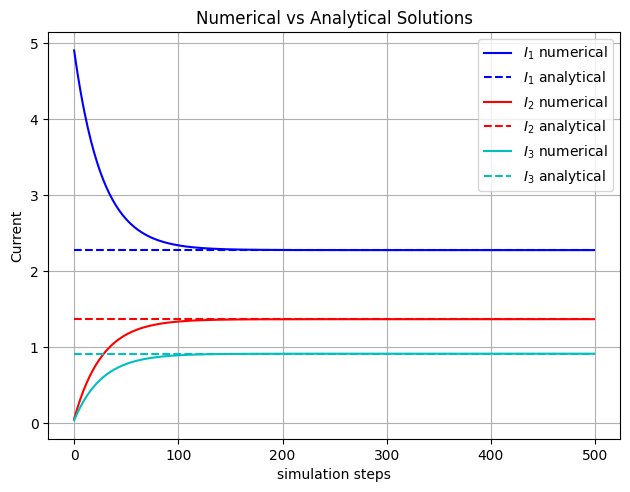

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V1 = 5 # fixed
V2 = 0 # not fixed
V3 = 0 # fixed

# some random resistor values
R1 = 1
R2 = 2
R3 = 3

# coupling matrix
G = np.array([
    [1/R1, -1/R1, 0],
    [0, 1/R2, -1/R2],
    [0, 1/R3, -1/R3]
])

# diagonal resistor matrix
R = np.diag([R1,R2,R3])


A = 2 * G.T @ R @ G 

vHist = []

nSteps = 500
dt = 1e-2

# voltage vector to be time stepped
v = np.array([V1, V2, V3]).reshape(3,1)

for i in range(nSteps):
    v = v - dt * A @ v 
    v[0] = V1
    v[2] = V3
    
    vHist.append(v.ravel() * 1)

vHist = np.array(vHist)

I_numerical = G @ vHist.T

r = R1 + (R2*R3)/(R2+R3)
I1_analytical = V1 / r
v2 = V1 - I1_analytical * R1
I2_analytical = v2 / R2
I3_analytical = v2/R3

# with plt.style.context("seaborn-v0_8-notebook"):
plt.plot(I_numerical[0], 'b', label='$I_1$ numerical')
plt.plot(np.ones(nSteps) * I1_analytical, 'b--', label='$I_1$ analytical')

plt.plot(I_numerical[1], 'r', label='$I_2$ numerical')
plt.plot(np.ones(nSteps) * I2_analytical, 'r--', label='$I_2$ analytical')

plt.plot(I_numerical[2], 'c', label='$I_3$ numerical')
plt.plot(np.ones(nSteps) * I3_analytical, 'c--', label='$I_3$ analytical')

plt.xlabel("simulation steps")
plt.ylabel("Current")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.title("Numerical vs Analytical Solutions")
plt.show()


